## 10 设计高效混合检索架构提升召回精度

### 1 混合检索的作用（Hybrid Search）

混合检索结合关键词匹配和语义搜索的优势，提供更准确、与上下文更相关的结果，进而让检索结果更全面。

例如，当搜索”苹果营养成分”时，混合检索既能找到包含”苹果”和”营养”关键词的文档，也能找到讨论”水果健康价值”等相关语义的内容，通过权重调整或重排序选出最优结果。

### 2 混合检索的架构（Hybrid Search Architecture）

混合检索架构通常包括关键词匹配、语义搜索和结果重排序等组件。

关键词匹配：使用 BM25 等传统的关键词匹配算法，快速筛选与查询关键词相关的文档。

语义搜索：利用向量空间模型（如 Word2Vec、BERT、GPT 等）将文档和查询转换为向量表示，通过余弦相似度计算文档与查询的相似性。

结果重排序：根据关键词匹配和语义搜索的结果，通过模型学习调整结果的排名顺序，提升与查询相关度较高的文档排名靠前。

### 3 混合检索的效果（Hybrid Search Effect）

混合检索的效果通常取决于架构设计、数据质量和模型训练。

较高的召回率：通过关键词匹配和语义搜索的组合，能够更全面地筛选相关文档，提升召回率。

较高的准确率：通过结果重排序模型，能够提升与查询相关的文档排名靠前的准确率，提升用户体验。

在复杂的信息检索任务中尤为有效。

### 4 以 Dify 为例，混合检索都有哪些常见的设置？

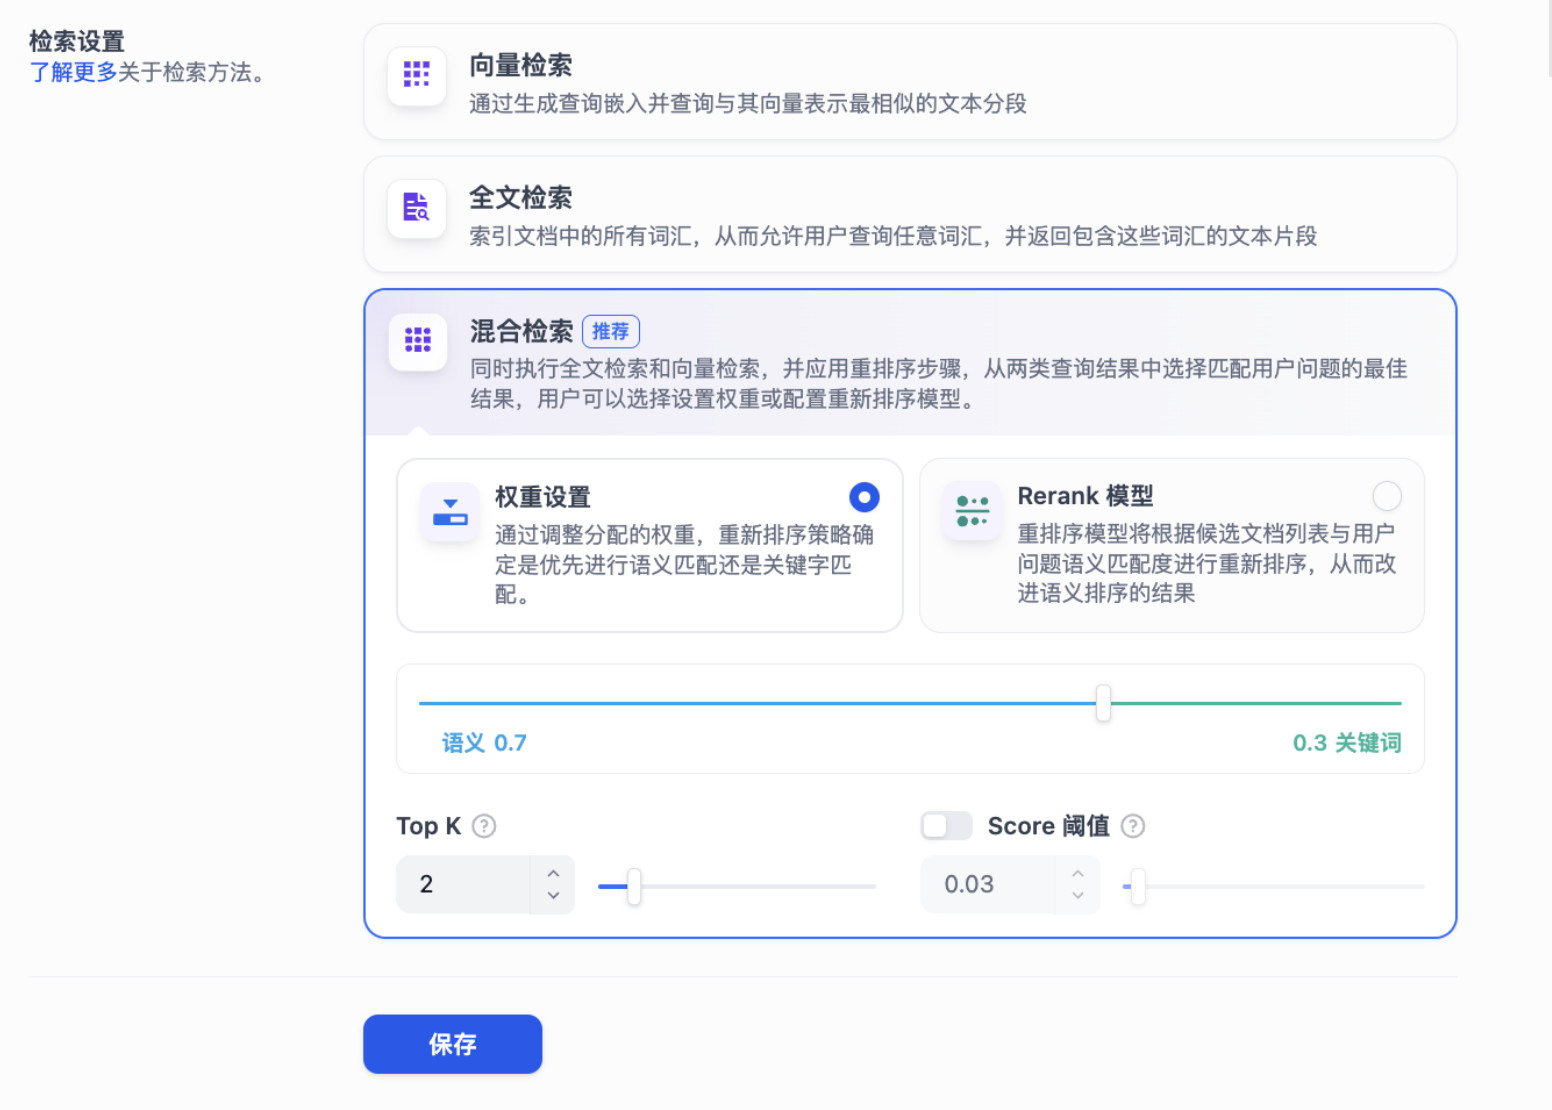

## 5 使用 Milvus + LlamaIndex 构建 混合检索
### 5.1 安装依赖项


In [8]:
! uv add llama-index-vector-stores-milvus llama-index-embeddings-openai llama-index-llms-openai

Resolved 157 packages in 1ms
Audited 137 packages in 6ms


### 5.2 启动 Milvus 服务器

docker compose up -d

注意：Milvus Standalone、Milvus Distributed 和 Zilliz Cloud 目前支持全文搜索，但 Milvus Lite 尚不支持全文搜索。

In [9]:
from llama_index.core import SimpleDirectoryReader
documents = SimpleDirectoryReader("./docs/").load_data()
print("Example document:\n", documents[0])

Example document:
 Doc ID: 001b2eda-f1a8-49e8-99b1-347d629e6a75
Text: 第一回：灵根育孕源流出，心性修持大道生 <p>诗曰：</p><p>混沌未分天地乱，茫茫渺渺无人见。</p><p>自从盘古破鸿蒙，
开辟从兹清浊辨。</p><p>覆载群生仰至仁，发明万物皆成善。</p><p>欲知造化会元功，须看西游释厄传。</p><p>盖闻天地之数，有十
二万九千六百岁为一元。将一元分为十二会，乃子、丑、寅、卯、辰、巳、午、未、申、酉、戌、亥之十二支也。每会该一万八百岁。且就一日而论：子时得阳
气，而丑则鸡鸣；寅不通光，而卯则日出；辰时食后，而巳则挨排；日午天中，而未则西蹉；申时晡而日落酉；戌黄昏而人定亥。譬于大数，若到戌会之终，则
天地昏蒙而万物否矣。再去五千四百岁，交亥会之初，则当黑暗，而两间人物俱无矣，故曰混沌。又五千四百岁，亥会将终，贞下起元，近子之会，而复逐渐开
明。邵...


### 5.3 使用 BM25 执行混合搜索

In [10]:
from llama_index.vector_stores.milvus import MilvusVectorStore
from llama_index.core import StorageContext, VectorStoreIndex

URI = "http://10.119.6.66:19530"

from llama_index.core import Settings
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

import os
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
custom_api_base = os.getenv("OPENAI_BASE_URL")

# 显式传入 api_key 和 api_base
Settings.llm = OpenAI(
    api_key=api_key, 
    api_base=custom_api_base,
    model="gpt-4o"
)
Settings.embed_model = OpenAIEmbedding(
    api_key=api_key, 
    api_base=custom_api_base,
    model_name="text-embedding-3-small"
)

vector_store = MilvusVectorStore(
    uri=URI,
    dim=1536,
    enable_sparse=True, # enable the default full-text search using BM25
    overwrite=True, # drop the collection if it already exists
)

storage_context = StorageContext.from_defaults(vector_store=vector_store)
index = VectorStoreIndex.from_documents(documents, storage_context=storage_context)


Sparse embedding function is not provided, using default.
Default sparse embedding function: BM25BuiltInFunction(input_field_names='text', output_field_names='sparse_embedding').


参数说明：

- dim (int, optional):Collections 的嵌入向量维度。
- enable_sparse (bool):用于启用或禁用稀疏嵌入。默认为假。




### 5.4 启用混合搜索

在查询阶段启用混合搜索，将vector_store_query_mode 设置为 "hybrid"。

开启后，将对语义搜索和全文搜索的搜索结果进行合并和 Rerankers。

In [11]:
import textwrap

query_engine = index.as_query_engine(
    vector_store_query_mode="hybrid", similarity_top_k=10
)

response = query_engine.query("孙悟空名字的由来？")

print(textwrap.fill(str(response), width=100))

for idx, node in enumerate(response.source_nodes, 1):
    print(f"Source Node {idx}: {textwrap.fill(str(node), width=100)}\n")

孙悟空的名字是由他的师父赐予的。师父认为猴王的身躯虽然鄙陋，但像个食松果的猢狲，于是决定给他取姓为“孙”。随后，师父根据门中的十二个字来分派名字，轮到猴王时正好是“悟”字，因此给他起了法名“孙悟空”。
猴王对此非常高兴，并从此以“孙悟空”自称。
Source Node 1: Node ID: eff24be0-7687-4545-8585-6ca1da01cca1 Text:
你起来走走我看。"猴王纵身跳起，拐呀拐的走了两遍。祖师笑道："你身躯虽是鄙陋，却像个食松果的猢狲。我与你就身上取个姓氏，意思教你
姓'猢'。猢字去了个兽傍，乃是古月。古者，老也；月者，阴也。老阴不能化育，教你姓'狲'倒好。狲字去了兽傍，乃是个子系。子者，儿男也；系者，婴
细也。正合婴儿之本论。教你姓'孙'罢。"猴王听说，满心欢喜，朝上叩头道："好！好！好！今日方知姓也。万望师父慈悲！既然有姓，再乞赐个名字，却
好呼唤。"祖师道："我门中有十二个字，分派起名到你乃第十辈之小徒矣。"猴王道："那十二个字？"祖师道："乃广、大、智、慧、真、如、性、海、颖
、悟、圆、觉十二字。排到你，正当'悟'字。与你起个法名叫做'孙悟空'好么？"猴王笑道："好！好！好！自今就叫做孙悟空也！"正是：</p><p >鸿蒙... Score:  0.016

Source Node 2: Node ID: 986e2974-5f5f-43d9-976a-725af2f8c279 Text:
我老师父护住山泉，并不曾白送与人。你回去办将礼来，我好通报，不然请回，莫想莫想！"行者道："人情大似圣旨，你去说我老孙的名字，他 必然做个人情，或者连井都送我也。"
那道人闻此言，只得进去通报，却见那真仙抚琴，只待他琴终，方才说道："师父，外面有个和尚，口称是唐三藏大徒
弟孙悟空，欲求落胎泉水，救他师父。"那真仙不听说便罢，一听得说个悟空名字，却就怒从心上起，恶向胆边生，急起身，下了琴床，脱了素服，换上道衣，
取一把如意钩子，跳出庵门，叫道："孙悟空何在？"行者转头，观见那真仙打扮： 头戴星冠飞彩艳，身穿金缕法衣红。 足下云鞋堆锦绣，腰间宝带绕玲珑。 一双纳锦凌波袜，半露裙襕闪绣绒。
手拿如意金钩子，鐏利杆长若蟒龙。 凤眼光明眉菂竖，钢牙尖利口翻红。 额下髯飘如烈火，鬓边赤发短蓬松。 形容恶... Score:  0.016

Sou

In [13]:
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
import textwrap

# 1. 加载文档
print("Loading documents...")
documents = SimpleDirectoryReader("./docs/").load_data()

# 2. 构建索引
print("Building index...")
index = VectorStoreIndex.from_documents(documents)

# 3. 设置混合检索参数
alpha = 0.1  # 权重参数：越大越偏向语义检索，越小偏向关键词检索
top_k = 10   # 返回前 top_k 个结果

retriever = index.as_retriever(
    retriever_mode="hybrid",
    alpha=alpha,
    similarity_top_k=top_k
)

query_engine = RetrieverQueryEngine(retriever=retriever)

# 5. 执行查询
query = "孙悟空名字的由来？"
print(f"\nQuery: {query}")
response = query_engine.query(query)
print("\nResponse:")
print(textwrap.fill(str(response), 100))

# 6. 输出来源文档片段
print("\nSource Nodes:")
for idx, node in enumerate(response.source_nodes, 1):
    print(f"结果 {idx}: ")
    print(textwrap.fill(str(node.node.text), 100))
    print("\n")

Loading documents...
Building index...

Query: 孙悟空名字的由来？

Response:
孙悟空的名字是由他的师父赐予的。师父认为猴王的身躯虽然鄙陋，但像个食松果的猢狲，于是决定给他取姓"孙"。随后，师父根据门派的十二个字辈，给他起了法名"孙悟空"，其中"悟"字正好是猴王所在的辈分。猴王对
此非常高兴，并从此以"孙悟空"为名。

Source Nodes:
结果 1: 
你起来走走我看。"猴王纵身跳起，拐呀拐的走了两遍。祖师笑道："你身躯虽是鄙陋，却像个食松果的猢狲。我与你就身上取个姓氏，意思教你姓'猢'。猢字去了个兽傍，乃是古月。古者，老也；月者，阴也。老阴不能化育
，教你姓'狲'倒好。狲字去了兽傍，乃是个子系。子者，儿男也；系者，婴细也。正合婴儿之本论。教你姓'孙'罢。"猴王听说，满心欢喜，朝上叩头道："好！好！好！今日方知姓也。万望师父慈悲！既然有姓，再乞赐个
名字，却好呼唤。"祖师道："我门中有十二个字，分派起名到你乃第十辈之小徒矣。"猴王道："那十二个字？"祖师道："乃广、大、智、慧、真、如、性、海、颖、悟、圆、觉十二字。排到你，正当'悟'字。与你起个法
名叫做'孙悟空'好么？"猴王笑道："好！好！好！自今就叫做孙悟空也！"正是：</p><p>鸿蒙初辟原无姓，打破顽空须悟空。</p><p>毕竟不知向后修些甚么道果，且听下回分解。</p>
第二回：悟彻菩提真妙理，断魔归本合元神 <p> 话表美猴王得了姓名，怡然踊跃；对菩提前作礼启谢。那祖师即命大众引悟空出二门外，教他洒扫应对，进退周旋之节。众仙奉行而出。悟空到门外，又拜了大众师兄，就于
廊庑之间，安排寝处。次早，与众师兄学言语礼貌、讲经论道，习字焚香，每日如此。闲时即扫地锄园，养花修树，寻柴燃火，挑水运浆。凡所用之物，无一不备。在洞中不觉倏六七年，一日，祖师登坛高坐，唤集诸仙，开讲大
道。真个是：</p><p> 天花乱坠，地涌金莲。妙演三乘教，精微万法全。慢摇麈尾喷珠玉，响振雷霆动九天。说一会道，讲一会禅，三家配合本如然。开明一字皈诚理，指引无生了性玄。</p><p>
孙悟空在旁闻听，喜得他抓耳挠腮，眉花眼笑。忍不住手之舞之，足之蹈之。


结果 2: 
我老师父护住山泉，并不曾白送与人。你回去办将礼来，我好通报，不然请回，莫想莫想！"行者道："人情大似圣旨，你

In [15]:
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
import textwrap

# 1. 加载文档
print("Loading documents...")
documents = SimpleDirectoryReader("./docs/").load_data()

# 2. 构建索引
print("Building index...")
index = VectorStoreIndex.from_documents(documents)

# 3. 设置混合检索参数
alpha = 0.9  # 权重参数：越大越偏向语义检索，越小偏向关键词检索
top_k = 10   # 返回前 top_k 个结果

retriever = index.as_retriever(
    retriever_mode="hybrid",
    alpha=alpha,
    similarity_top_k=top_k
)

query_engine = RetrieverQueryEngine(retriever=retriever)

# 5. 执行查询
query = "孙悟空名字的由来？"
print(f"\nQuery: {query}")
response = query_engine.query(query)
print("\nResponse:")
print(textwrap.fill(str(response), 100))

# 6. 输出来源文档片段
print("\nSource Nodes:")
for idx, node in enumerate(response.source_nodes, 1):
    print(f"结果 {idx}: ")
    print(textwrap.fill(str(node.node.text), 100))
    print("\n")

Loading documents...
Building index...

Query: 孙悟空名字的由来？

Response:
孙悟空的名字是由他的师父赐予的。师父认为猴王的身躯虽然鄙陋，但像个食松果的猢狲，于是决定给他取姓氏。经过一番解释，最终决定去掉“猢”字的兽旁，改为“孙”姓。随后，师父根据门中十二个字的辈分，给他取法名
为“孙悟空”。这个名字寓意着打破顽空，须悟空。

Source Nodes:
结果 1: 
你起来走走我看。"猴王纵身跳起，拐呀拐的走了两遍。祖师笑道："你身躯虽是鄙陋，却像个食松果的猢狲。我与你就身上取个姓氏，意思教你姓'猢'。猢字去了个兽傍，乃是古月。古者，老也；月者，阴也。老阴不能化育
，教你姓'狲'倒好。狲字去了兽傍，乃是个子系。子者，儿男也；系者，婴细也。正合婴儿之本论。教你姓'孙'罢。"猴王听说，满心欢喜，朝上叩头道："好！好！好！今日方知姓也。万望师父慈悲！既然有姓，再乞赐个
名字，却好呼唤。"祖师道："我门中有十二个字，分派起名到你乃第十辈之小徒矣。"猴王道："那十二个字？"祖师道："乃广、大、智、慧、真、如、性、海、颖、悟、圆、觉十二字。排到你，正当'悟'字。与你起个法
名叫做'孙悟空'好么？"猴王笑道："好！好！好！自今就叫做孙悟空也！"正是：</p><p>鸿蒙初辟原无姓，打破顽空须悟空。</p><p>毕竟不知向后修些甚么道果，且听下回分解。</p>
第二回：悟彻菩提真妙理，断魔归本合元神 <p> 话表美猴王得了姓名，怡然踊跃；对菩提前作礼启谢。那祖师即命大众引悟空出二门外，教他洒扫应对，进退周旋之节。众仙奉行而出。悟空到门外，又拜了大众师兄，就于
廊庑之间，安排寝处。次早，与众师兄学言语礼貌、讲经论道，习字焚香，每日如此。闲时即扫地锄园，养花修树，寻柴燃火，挑水运浆。凡所用之物，无一不备。在洞中不觉倏六七年，一日，祖师登坛高坐，唤集诸仙，开讲大
道。真个是：</p><p> 天花乱坠，地涌金莲。妙演三乘教，精微万法全。慢摇麈尾喷珠玉，响振雷霆动九天。说一会道，讲一会禅，三家配合本如然。开明一字皈诚理，指引无生了性玄。</p><p>
孙悟空在旁闻听，喜得他抓耳挠腮，眉花眼笑。忍不住手之舞之，足之蹈之。


结果 2: 
我老师父护住山泉，并不曾白送与人。你回去办将礼来，我好通报，不然请回，莫想莫想！"行者道："人情大

### 5.5 加权平均（Weighted Average）

LlamaIndex 支持通过 alpha 参数对语义和关键词检索结果进行线性加权融合。
- alpha=1.0 表示完全依赖语义检索
- alpha=0.0 表示完全依赖关键词检索
- 中间值则表示两者加权融合

⚠️ 注意：这种加权方式是基于得分直接加权，并不是严格的归一化后加权。

## 6 扩展

支持混合检索的平台、工具及其稀疏嵌入方法

| 平台/工具                   | 示例稀疏嵌入方法                                      | 说明                                                                                     |
|----------------------------|-------------------------------------------------------|------------------------------------------------------------------------------------------|
| Qdrant + LlamaIndex          | BM42                                                  | 提供轻量级稀疏嵌入方法，并与语义向量结合实现高效的混合搜索 [[1]]                          |
| Milvus + LlamaIndex          | BM25BuiltInFunction                                  | 默认支持使用 BM25 对文本进行分词和权重计算，适用于关键词匹配场景 [[4]]                     |
| Milvus + LlamaIndex          | BGEM3SparseEmbeddingFunction                         | 使用 BGE-M3 模型生成稀疏嵌入，结合语义理解与关键词匹配 [[9]]                               |
| Milvus + LlamaIndex          | 自定义稀疏嵌入函数（如继承 BaseSparseEmbeddingFunction） | 支持用户自定义稀疏嵌入方法，如基于神经模型的稀疏表示 [[5]]                                 |
| Milvus                       | TF-IDF、BM25、SPLADEv2 稀疏向量                      | Milvus 原生支持多种稀疏向量格式，可与稠密向量同等处理，扩展了混合搜索功能 [[3]][[6]]       |
| BGE-M3                       | 内置词元权重（模拟 BM25 效果）                       | 不仅支持密集嵌入，还能生成类似 BM25 的稀疏表示，用于混合检索 [[9]]                         |                           |
| Elasticsearch                | Elastic Learned Sparse Encoder                       | 使用训练好的模型理解稀疏向量嵌入，并结合密集向量进行混合搜索 [[8]]                           |
| 自定义系统                   | BM25、TF-IDF、Sparse Transformers                    | 可集成任意稀疏嵌入，实现灵活的多源混合检索                                                 |